In [2]:
import json
import pandas as pd
from pathlib import Path

# Load the result
with open('MIA_results.json', 'r') as f:
    combined_df = json.load(f)
combined_df= pd.DataFrame(combined_df).T

In [3]:
import pandas as pd
import json

def flatten_results_to_dataframe(df, results_column='results'):
    """
    Flatten nested JSON results into a long-format dataframe suitable for analysis.
    
    Parameters:
    df: DataFrame with a column containing JSON strings
    results_column: Name of the column containing the JSON data
    
    Returns:
    DataFrame with columns: index, method_key, measurement_type, value
    """
    
    flattened_data = []
    
    for idx, row in df.iterrows():
        # Parse the JSON string
        if pd.isna(row[results_column]):
            continue
            
        try:
            # Handle both string and dict formats
            if isinstance(row[results_column], str):
                data = json.loads(row[results_column])
            else:
                data = row[results_column]
        except (json.JSONDecodeError, TypeError):
            print(f"Warning: Could not parse JSON for index {idx}")
            continue
        
        # Extract privacy attacks
        if 'privacy_attacks' in data:
            for method_key, metrics in data['privacy_attacks'].items():
                for metric_name, metric_value in metrics.items():
                    # Skip metadata
                    if metric_name == '_metadata':
                        continue
                    
                    flattened_data.append({
                        'index': idx,
                        'method_key': method_key,
                        'measurement_type': f'privacy_{metric_name}',
                        'value': metric_value
                    })
        
        # Extract utility evaluation
        if 'utility_evaluation' in data:
            for metric_name, metric_value in data['utility_evaluation'].items():
                # Skip non-numeric fields that might be complex
                if metric_name in ['categorical_columns', 'label_mapping']:
                    continue
                
                flattened_data.append({
                    'index': idx,
                    'method_key': 'utility',
                    'measurement_type': f'utility_{metric_name}',
                    'value': metric_value
                })
        
        # Extract statistical metrics
        if 'statistical_metrics' in data:
            for metric_name, metric_value in data['statistical_metrics'].items():
                # Handle shape tuples
                if metric_name in ['real_shape', 'syn_shape']:
                    # Convert shape tuple to string or extract dimensions
                    if isinstance(metric_value, list) and len(metric_value) == 2:
                        flattened_data.append({
                            'index': idx,
                            'method_key': 'statistical',
                            'measurement_type': f'{metric_name}_rows',
                            'value': metric_value[0]
                        })
                        flattened_data.append({
                            'index': idx,
                            'method_key': 'statistical',
                            'measurement_type': f'{metric_name}_cols',
                            'value': metric_value[1]
                        })
                    continue
                
                flattened_data.append({
                    'index': idx,
                    'method_key': 'statistical',
                    'measurement_type': f'statistical_{metric_name}',
                    'value': metric_value
                })
    
    return pd.DataFrame(flattened_data)

# Example usage with your data structure:
# Assuming your dataframe is called 'df' and has a 'results' column
# flattened_df = flatten_results_to_dataframe(df, 'results')

# Demonstrate the flattening
result_df = flatten_results_to_dataframe(combined_df, 'results')
print("Flattened DataFrame:")
result_df[['dataset', 'model', 'seed', 'synth_ratio']] = result_df['index'].str.split('/', expand=True)

Flattened DataFrame:


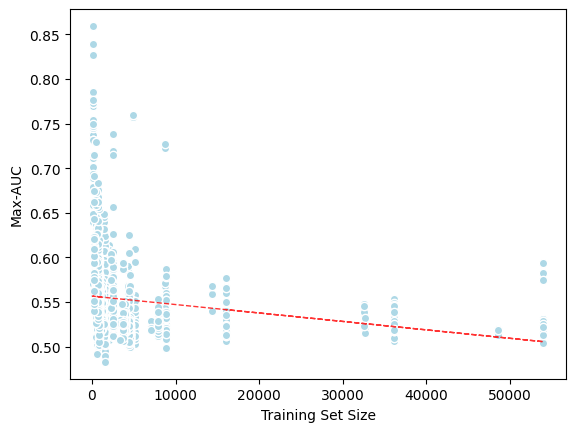

Pearson correlation: -0.2390
P-value: 1.3996350724631644e-24


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
# Filter out rows where model != 'great'
filtered_df = result_df[result_df['model'] != 'great']

y_df = filtered_df[(filtered_df['measurement_type'] == 'privacy_auc_roc') & (filtered_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().reset_index().rename(columns={'value': 'privacy'})

x_df = filtered_df[(filtered_df['measurement_type'] == 'syn_shape_rows') & (filtered_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().reset_index().rename(columns={'value': 'mmd'})

merged = y_df.merge(x_df, on=['dataset', 'model', 'seed', 'synth_ratio'])

y = pd.to_numeric(merged['privacy'])
x = pd.to_numeric(merged['mmd'])

plt.scatter(x, y, c='lightblue', edgecolors='white', linewidth=1)

# Add best fit line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "red", linewidth=1, linestyle='--', alpha=0.8)

plt.ylabel('Max-AUC')
plt.xlabel('Training Set Size')
plt.savefig('auc_training_size.png', dpi=300, bbox_inches='tight')
plt.show()

correlation, p_value = stats.pearsonr(x, y)
print(f"Pearson correlation: {correlation:.4f}")
print(f"P-value: {p_value}")

# Anova

In [6]:
measurement_type = 'privacy_auc_roc'
exclude_models = ['autodiff', 'tabsyn', 'great']

# Filter relevant measurement
df = result_df[result_df['measurement_type'] == measurement_type].copy()

# Exclude specified models
df = df[~df['model'].isin(exclude_models)]

# Group to get max values
grouped = df.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().reset_index()

# Create unique experiment ID
grouped['experiment_id'] = grouped['dataset'] + "_" + grouped['model'] + "_" + grouped['seed'].astype(str)

# Pivot the data
pivot_df = grouped.pivot(index='experiment_id', columns='synth_ratio', values='value')
pivot_df = pivot_df.dropna()  # Drop incomplete rows


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.anova import AnovaRM
from itertools import combinations
anova_df = pivot_df.reset_index().melt(id_vars='experiment_id', var_name='synth_ratio', value_name='value')
anova_df['synth_ratio'] = anova_df['synth_ratio'].astype(str)

aovrm = AnovaRM(anova_df, depvar='value', subject='experiment_id', within=['synth_ratio'])
anova_results = aovrm.fit()
print(anova_results)

p_value = anova_results.anova_table['Pr > F'][0]
alpha = 0.05

print(f"Significant differences: {p_value < alpha} (p = {p_value:.6f})")


                   Anova
            F Value Num DF   Den DF  Pr > F
-------------------------------------------
synth_ratio 76.0431 2.0000 2318.0000 0.0000

Significant differences: True (p = 0.000000)


/tmp/ipykernel_3776588/4184392153.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results.anova_table['Pr > F'][0]


                   Anova
            F Value Num DF   Den DF  Pr > F
-------------------------------------------
synth_ratio 76.0431 2.0000 2318.0000 0.0000

Significant differences: True (p = 0.000000)


/tmp/ipykernel_3776588/3976894201.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results.anova_table['Pr > F'][0]
/tmp/ipykernel_3776588/3976894201.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  F_stat = anova_results.anova_table['F Value'][0]
/tmp/ipykernel_3776588/3976894201.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results.anova_table['Pr > F'][0]
/tmp/ipykernel_3776588/39768

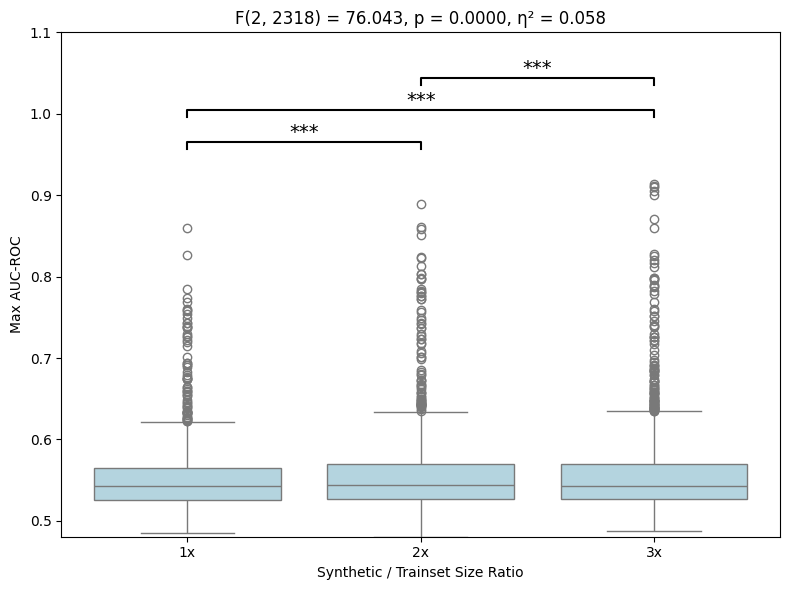

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_rel
import numpy as np
import pandas as pd
measurement_type = 'privacy_auc_roc'
exclude_models = ['autodiff', 'tabsyn', 'great']

# Filter relevant measurement
df = result_df[result_df['measurement_type'] == measurement_type].copy()

# Exclude specified models
df = df[~df['model'].isin(exclude_models)]

# Group to get max values
grouped = df.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().reset_index()

# Create unique experiment ID
grouped['experiment_id'] = grouped['dataset'] + "_" + grouped['model'] + "_" + grouped['seed'].astype(str)

# Pivot the data
pivot_df = grouped.pivot(index='experiment_id', columns='synth_ratio', values='value')
pivot_df = pivot_df.dropna()  # Drop incomplete rows


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.anova import AnovaRM
from itertools import combinations
anova_df = pivot_df.reset_index().melt(id_vars='experiment_id', var_name='synth_ratio', value_name='value')
anova_df['synth_ratio'] = anova_df['synth_ratio'].astype(str)

aovrm = AnovaRM(anova_df, depvar='value', subject='experiment_id', within=['synth_ratio'])
anova_results = aovrm.fit()
print(anova_results)

p_value = anova_results.anova_table['Pr > F'][0]
alpha = 0.05

print(f"Significant differences: {p_value < alpha} (p = {p_value:.6f})")

# Prepare data in long format for seaborn
pivot_df_reset = pivot_df.reset_index()
data_melted = pivot_df_reset.melt(
    id_vars=['experiment_id'], 
    var_name='synth_ratio', 
    value_name='value'
)

# Function to extract numeric ratio for sorting
def extract_numeric_ratio(col_name):
    val = col_name.replace('synth_', '').rstrip('x')
    return float(val)

# Sort levels meaningfully
sorted_levels = sorted(data_melted['synth_ratio'].unique(), key=extract_numeric_ratio)

# Create cleaned labels (drop 'synth_')
label_map = {lvl: lvl.replace("synth_", "") for lvl in sorted_levels}
data_melted["synth_ratio_clean"] = data_melted["synth_ratio"].map(label_map)
sorted_levels_clean = [label_map[lvl] for lvl in sorted_levels]

# --- Extract ANOVA results ---
F_stat = anova_results.anova_table['F Value'][0]
p_value = anova_results.anova_table['Pr > F'][0]
ss_effect = anova_results.anova_table['Num DF'][0] * anova_results.anova_table['F Value'][0] * anova_results.anova_table['Den DF'][0] / (
    anova_results.anova_table['Den DF'][0] + anova_results.anova_table['Num DF'][0] * anova_results.anova_table['F Value'][0]
)
ss_total = ss_effect + anova_results.anova_table['Den DF'][0]
eta_sq = ss_effect / ss_total

# --- Plot ---
plt.figure(figsize=(8,6))
sns.boxplot(
    data=data_melted, 
    x='synth_ratio_clean', 
    y='value', 
    order=sorted_levels_clean, 
    color='lightblue'
)

plt.xlabel('Synthetic / Trainset Size Ratio')
plt.ylabel('Max AUC-ROC')
plt.title(f'F({int(anova_results.anova_table["Num DF"][0])}, {int(anova_results.anova_table["Den DF"][0])}) = {F_stat:.3f}, '
          f'p = {p_value:.4f}, η² = {eta_sq:.3f}')

# Paired t-tests with Bonferroni correction
comparisons = list(combinations(sorted_levels, 2))
alpha = 0.05
bonferroni_alpha = alpha / len(comparisons)

y_max = data_melted['value'].max()
y_min = data_melted['value'].min()
height = y_max - y_min
line_height = y_max + height*0.1
star_y = []

for i, (a, b) in enumerate(comparisons):
    # Convert to numeric
    df_a = pd.to_numeric(pivot_df[a], errors='coerce')
    df_b = pd.to_numeric(pivot_df[b], errors='coerce')

    # Paired t-test (drop NA)
    mask = df_a.notna() & df_b.notna()
    stat, p = ttest_rel(df_a[mask], df_b[mask])

    # Bonferroni-adjusted p-value
    p_adj = min(p * len(comparisons), 1.0)
            
    # Determine significance stars
    if p_adj < 0.001:
        stars = '***'
    elif p_adj < 0.01:
        stars = '**'
    elif p_adj < 0.05:
        stars = '*'
    else:
        stars = 'ns'
    
    # x positions of groups (using cleaned labels)
    x1 = sorted_levels_clean.index(label_map[a])
    x2 = sorted_levels_clean.index(label_map[b])
    
    # y position for the line and stars
    y = line_height + i*height*0.09
    star_y.append(y)
    
    # Draw lines
    plt.plot([x1, x1, x2, x2], [y, y+height*0.02, y+height*0.02, y], lw=1.5, c='k')
    # Draw stars
    plt.text((x1+x2)*.5, y+height*0.02, stars, ha='center', va='bottom', color='k', fontsize=14)

plt.ylim(y_min, max(star_y)+height*0.15)
plt.tight_layout()
plt.savefig("1wayanova_boxplot.png", dpi=300, bbox_inches="tight")  # save as PNG
plt.show()


                   Anova
            F Value Num DF   Den DF  Pr > F
-------------------------------------------
synth_ratio 12.9962 2.0000 2318.0000 0.0000

Significant differences: True (p = 0.000002)


/tmp/ipykernel_31319/941373986.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results.anova_table['Pr > F'][0]
/tmp/ipykernel_31319/941373986.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  F_stat = anova_results.anova_table['F Value'][0]
/tmp/ipykernel_31319/941373986.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results.anova_table['Pr > F'][0]
/tmp/ipykernel_31319/941373986.py:70:

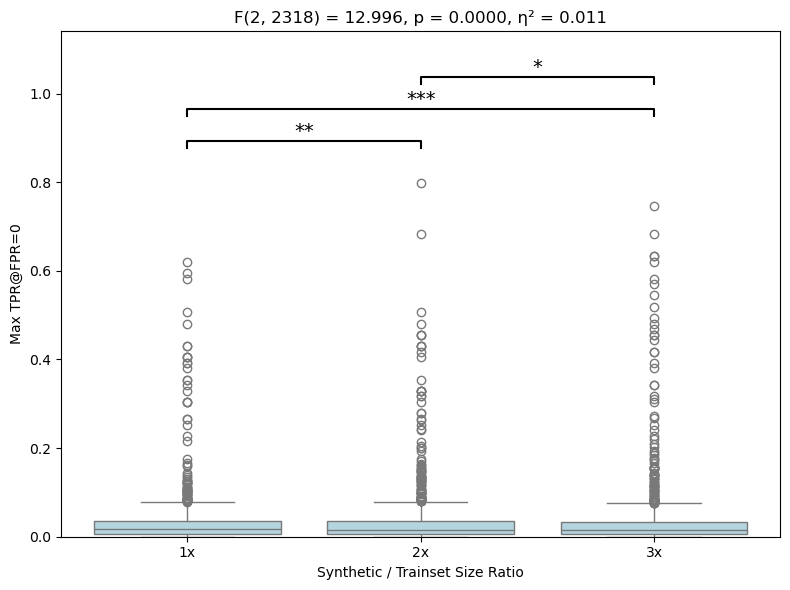

In [340]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_rel
import numpy as np
import pandas as pd
measurement_type = 'privacy_tpr_at_fpr_0'
exclude_models = ['autodiff', 'tabsyn', 'great']

# Filter relevant measurement
df = result_df[result_df['measurement_type'] == measurement_type].copy()

# Exclude specified models
df = df[~df['model'].isin(exclude_models)]

# Group to get max values
grouped = df.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().reset_index()

# Create unique experiment ID
grouped['experiment_id'] = grouped['dataset'] + "_" + grouped['model'] + "_" + grouped['seed'].astype(str)

# Pivot the data
pivot_df = grouped.pivot(index='experiment_id', columns='synth_ratio', values='value')
pivot_df = pivot_df.dropna()  # Drop incomplete rows


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.anova import AnovaRM
from itertools import combinations
anova_df = pivot_df.reset_index().melt(id_vars='experiment_id', var_name='synth_ratio', value_name='value')
anova_df['synth_ratio'] = anova_df['synth_ratio'].astype(str)

aovrm = AnovaRM(anova_df, depvar='value', subject='experiment_id', within=['synth_ratio'])
anova_results = aovrm.fit()
print(anova_results)

p_value = anova_results.anova_table['Pr > F'][0]
alpha = 0.05

print(f"Significant differences: {p_value < alpha} (p = {p_value:.6f})")

# Prepare data in long format for seaborn
pivot_df_reset = pivot_df.reset_index()
data_melted = pivot_df_reset.melt(
    id_vars=['experiment_id'], 
    var_name='synth_ratio', 
    value_name='value'
)

# Function to extract numeric ratio for sorting
def extract_numeric_ratio(col_name):
    val = col_name.replace('synth_', '').rstrip('x')
    return float(val)

# Sort levels meaningfully
sorted_levels = sorted(data_melted['synth_ratio'].unique(), key=extract_numeric_ratio)

# Create cleaned labels (drop 'synth_')
label_map = {lvl: lvl.replace("synth_", "") for lvl in sorted_levels}
data_melted["synth_ratio_clean"] = data_melted["synth_ratio"].map(label_map)
sorted_levels_clean = [label_map[lvl] for lvl in sorted_levels]

# --- Extract ANOVA results ---
F_stat = anova_results.anova_table['F Value'][0]
p_value = anova_results.anova_table['Pr > F'][0]
ss_effect = anova_results.anova_table['Num DF'][0] * anova_results.anova_table['F Value'][0] * anova_results.anova_table['Den DF'][0] / (
    anova_results.anova_table['Den DF'][0] + anova_results.anova_table['Num DF'][0] * anova_results.anova_table['F Value'][0]
)
ss_total = ss_effect + anova_results.anova_table['Den DF'][0]
eta_sq = ss_effect / ss_total

# --- Plot ---
plt.figure(figsize=(8,6))
sns.boxplot(
    data=data_melted, 
    x='synth_ratio_clean', 
    y='value', 
    order=sorted_levels_clean, 
    color='lightblue'
)

plt.xlabel('Synthetic / Trainset Size Ratio')
plt.ylabel('Max TPR@FPR=0')
plt.title(f'F({int(anova_results.anova_table["Num DF"][0])}, {int(anova_results.anova_table["Den DF"][0])}) = {F_stat:.3f}, '
          f'p = {p_value:.4f}, η² = {eta_sq:.3f}')

# Paired t-tests with Bonferroni correction
comparisons = list(combinations(sorted_levels, 2))
alpha = 0.05
bonferroni_alpha = alpha / len(comparisons)

y_max = data_melted['value'].max()
y_min = data_melted['value'].min()
height = y_max - y_min
line_height = y_max + height*0.1
star_y = []

for i, (a, b) in enumerate(comparisons):
    # Convert to numeric
    df_a = pd.to_numeric(pivot_df[a], errors='coerce')
    df_b = pd.to_numeric(pivot_df[b], errors='coerce')

    # Paired t-test (drop NA)
    mask = df_a.notna() & df_b.notna()
    stat, p = ttest_rel(df_a[mask], df_b[mask])

    # Bonferroni-adjusted p-value
    p_adj = min(p * len(comparisons), 1.0)
            
    # Determine significance stars
    if p_adj < 0.001:
        stars = '***'
    elif p_adj < 0.01:
        stars = '**'
    elif p_adj < 0.05:
        stars = '*'
    else:
        stars = 'ns'
    
    # x positions of groups (using cleaned labels)
    x1 = sorted_levels_clean.index(label_map[a])
    x2 = sorted_levels_clean.index(label_map[b])
    
    # y position for the line and stars
    y = line_height + i*height*0.09
    star_y.append(y)
    
    # Draw lines
    plt.plot([x1, x1, x2, x2], [y, y+height*0.02, y+height*0.02, y], lw=1.5, c='k')
    # Draw stars
    plt.text((x1+x2)*.5, y+height*0.02, stars, ha='center', va='bottom', color='k', fontsize=14)

plt.ylim(y_min, max(star_y)+height*0.15)
plt.tight_layout()
plt.savefig("1wayanova_tpr_0_boxplot.png", dpi=300, bbox_inches="tight")  # save as PNG
plt.show()


                   Anova
            F Value Num DF   Den DF  Pr > F
-------------------------------------------
synth_ratio 30.8059 2.0000 2318.0000 0.0000

Significant differences: True (p = 0.000000)


/tmp/ipykernel_31319/884473117.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results.anova_table['Pr > F'][0]
/tmp/ipykernel_31319/884473117.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  F_stat = anova_results.anova_table['F Value'][0]
/tmp/ipykernel_31319/884473117.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results.anova_table['Pr > F'][0]
/tmp/ipykernel_31319/884473117.py:70:

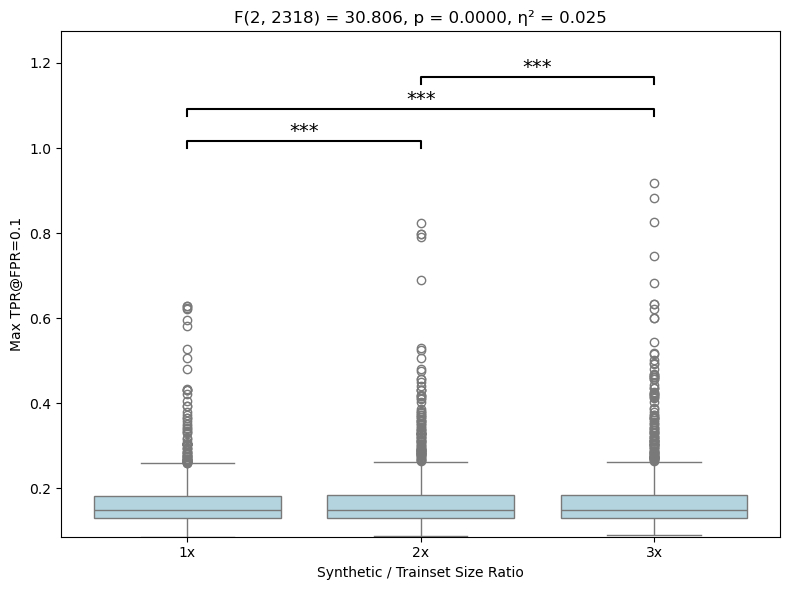

In [341]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_rel
import numpy as np
import pandas as pd
measurement_type = 'privacy_tpr_at_fpr_0.1'
exclude_models = ['autodiff', 'tabsyn', 'great']

# Filter relevant measurement
df = result_df[result_df['measurement_type'] == measurement_type].copy()

# Exclude specified models
df = df[~df['model'].isin(exclude_models)]

# Group to get max values
grouped = df.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().reset_index()

# Create unique experiment ID
grouped['experiment_id'] = grouped['dataset'] + "_" + grouped['model'] + "_" + grouped['seed'].astype(str)

# Pivot the data
pivot_df = grouped.pivot(index='experiment_id', columns='synth_ratio', values='value')
pivot_df = pivot_df.dropna()  # Drop incomplete rows


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.anova import AnovaRM
from itertools import combinations
anova_df = pivot_df.reset_index().melt(id_vars='experiment_id', var_name='synth_ratio', value_name='value')
anova_df['synth_ratio'] = anova_df['synth_ratio'].astype(str)

aovrm = AnovaRM(anova_df, depvar='value', subject='experiment_id', within=['synth_ratio'])
anova_results = aovrm.fit()
print(anova_results)

p_value = anova_results.anova_table['Pr > F'][0]
alpha = 0.05

print(f"Significant differences: {p_value < alpha} (p = {p_value:.6f})")

# Prepare data in long format for seaborn
pivot_df_reset = pivot_df.reset_index()
data_melted = pivot_df_reset.melt(
    id_vars=['experiment_id'], 
    var_name='synth_ratio', 
    value_name='value'
)

# Function to extract numeric ratio for sorting
def extract_numeric_ratio(col_name):
    val = col_name.replace('synth_', '').rstrip('x')
    return float(val)

# Sort levels meaningfully
sorted_levels = sorted(data_melted['synth_ratio'].unique(), key=extract_numeric_ratio)

# Create cleaned labels (drop 'synth_')
label_map = {lvl: lvl.replace("synth_", "") for lvl in sorted_levels}
data_melted["synth_ratio_clean"] = data_melted["synth_ratio"].map(label_map)
sorted_levels_clean = [label_map[lvl] for lvl in sorted_levels]

# --- Extract ANOVA results ---
F_stat = anova_results.anova_table['F Value'][0]
p_value = anova_results.anova_table['Pr > F'][0]
ss_effect = anova_results.anova_table['Num DF'][0] * anova_results.anova_table['F Value'][0] * anova_results.anova_table['Den DF'][0] / (
    anova_results.anova_table['Den DF'][0] + anova_results.anova_table['Num DF'][0] * anova_results.anova_table['F Value'][0]
)
ss_total = ss_effect + anova_results.anova_table['Den DF'][0]
eta_sq = ss_effect / ss_total

# --- Plot ---
plt.figure(figsize=(8,6))
sns.boxplot(
    data=data_melted, 
    x='synth_ratio_clean', 
    y='value', 
    order=sorted_levels_clean, 
    color='lightblue'
)

plt.xlabel('Synthetic / Trainset Size Ratio')
plt.ylabel('Max TPR@FPR=0.1')
plt.title(f'F({int(anova_results.anova_table["Num DF"][0])}, {int(anova_results.anova_table["Den DF"][0])}) = {F_stat:.3f}, '
          f'p = {p_value:.4f}, η² = {eta_sq:.3f}')

# Paired t-tests with Bonferroni correction
comparisons = list(combinations(sorted_levels, 2))
alpha = 0.05
bonferroni_alpha = alpha / len(comparisons)

y_max = data_melted['value'].max()
y_min = data_melted['value'].min()
height = y_max - y_min
line_height = y_max + height*0.1
star_y = []

for i, (a, b) in enumerate(comparisons):
    # Convert to numeric
    df_a = pd.to_numeric(pivot_df[a], errors='coerce')
    df_b = pd.to_numeric(pivot_df[b], errors='coerce')

    # Paired t-test (drop NA)
    mask = df_a.notna() & df_b.notna()
    stat, p = ttest_rel(df_a[mask], df_b[mask])

    # Bonferroni-adjusted p-value
    p_adj = min(p * len(comparisons), 1.0)
            
    # Determine significance stars
    if p_adj < 0.001:
        stars = '***'
    elif p_adj < 0.01:
        stars = '**'
    elif p_adj < 0.05:
        stars = '*'
    else:
        stars = 'ns'
    
    # x positions of groups (using cleaned labels)
    x1 = sorted_levels_clean.index(label_map[a])
    x2 = sorted_levels_clean.index(label_map[b])
    
    # y position for the line and stars
    y = line_height + i*height*0.09
    star_y.append(y)
    
    # Draw lines
    plt.plot([x1, x1, x2, x2], [y, y+height*0.02, y+height*0.02, y], lw=1.5, c='k')
    # Draw stars
    plt.text((x1+x2)*.5, y+height*0.02, stars, ha='center', va='bottom', color='k', fontsize=14)

plt.ylim(y_min, max(star_y)+height*0.15)
plt.tight_layout()
plt.savefig("1wayanova_tpr_01_boxplot.png", dpi=300, bbox_inches="tight")  # save as PNG
plt.show()


In [124]:
temp = result_df[(result_df['measurement_type'] == 'privacy_tpr_at_fpr_0.1') & (result_df['synth_ratio'] == 'synth_1x')].copy()

# Create method groups
temp['method_group'] = temp['method_key'].str.extract('(GenLRA|DPI)', expand=False).fillna(temp['method_key'])

# Get max within groups for each experiment run
grouped = temp.groupby(['dataset', 'model', 'seed', 'synth_ratio', 'method_group'])['value'].max().reset_index()

# Rank methods within each run
grouped['rank'] = grouped.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].rank(method='average', ascending=False)

# Find which method(s) got the top rank in each run
grouped['is_top'] = grouped['rank'] == 1

# Proportion of times each method was top
top_proportion = grouped.groupby('method_group')['is_top'].mean()
print(top_proportion)


method_group
Classifier             0.081096
DCR                    0.070470
DCR-Diff               0.139821
DOMIAS                 0.066617
DPI                    0.218121
DensityEstimate_kde    0.067187
GenLRA                 0.287129
LOGAN                  0.085011
Local Neighborhood     0.021253
MC                     0.054251
Name: is_top, dtype: float64


method_group
Classifier             0.081096
DCR                    0.070470
DCR-Diff               0.139821
DOMIAS                 0.066617
DPI                    0.218121
DensityEstimate_kde    0.067187
GenLRA                 0.287129
LOGAN                  0.085011
Local Neighborhood     0.021253
MC                     0.054251
Name: is_top, dtype: float64


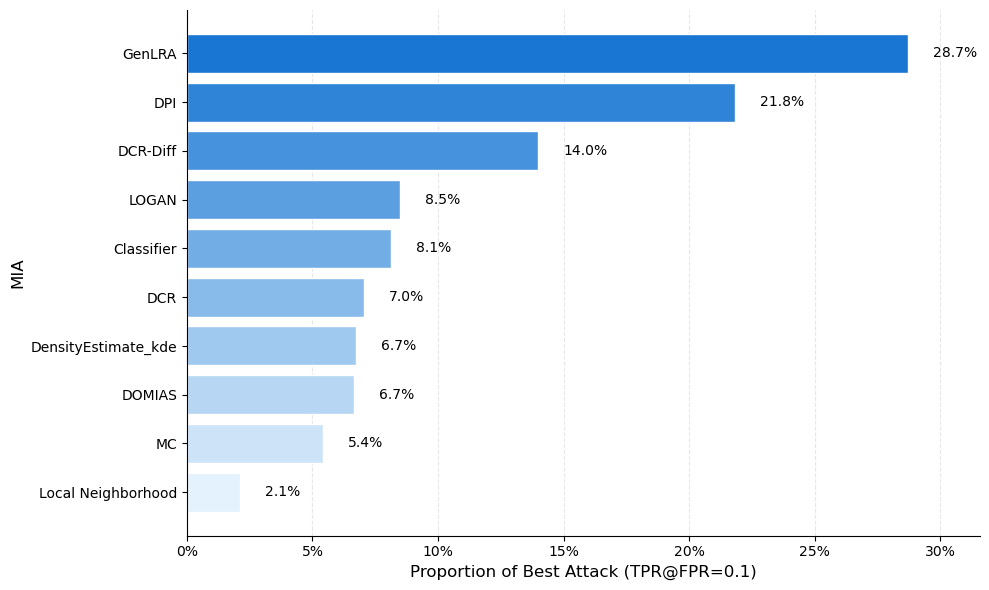

In [315]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

temp = result_df[(result_df['measurement_type'] == 'privacy_tpr_at_fpr_0.1') & (result_df['synth_ratio'] == 'synth_1x')].copy()

# Create method groups
temp['method_group'] = temp['method_key'].str.extract('(GenLRA|DPI)', expand=False).fillna(temp['method_key'])

# Get max within groups for each experiment run
grouped = temp.groupby(['dataset', 'model', 'seed', 'synth_ratio', 'method_group'])['value'].max().reset_index()

# Rank methods within each run
grouped['rank'] = grouped.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].rank(method='average', ascending=False)

# Find which method(s) got the top rank in each run
grouped['is_top'] = grouped['rank'] == 1

# Proportion of times each method was top
top_proportion = grouped.groupby('method_group')['is_top'].mean()
print(top_proportion)

data = top_proportion
sorted_data = dict(sorted(data.items(), key=lambda x: x[1]))
methods = list(sorted_data.keys())
proportions = list(sorted_data.values())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create light blue gradient colormap
colors = ['#E3F2FD', '#1976D2']  # Light blue to medium blue
n_bars = len(methods)
cmap = LinearSegmentedColormap.from_list('light_blue', colors, N=n_bars)

# Create bars with gradient colors
bars = ax.barh(methods, proportions, 
               color=[cmap(i/max(1, n_bars-1)) for i in range(n_bars)],
               edgecolor='white', linewidth=1)

# Customize the chart
ax.set_xlabel('Proportion of Best Attack (TPR@FPR=0.1)', fontsize=12)
ax.set_ylabel('MIA', fontsize=12)

# Set x-axis limits and format
ax.set_xlim(0, max(proportions) * 1.1)

# Format x-axis as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))

# Add value labels on bars as percentages
for i, (bar, value) in enumerate(zip(bars, proportions)):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{value*100:.1f}%', ha='left', va='center')

# Improve styling
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('prop_best_tpr_fpr.png', dpi=300, bbox_inches='tight')

plt.show()

method_group
Classifier             0.105705
DCR                    0.079418
DCR-Diff               0.118568
DOMIAS                 0.054641
DPI                    0.250000
DensityEstimate_kde    0.053989
GenLRA                 0.254125
LOGAN                  0.122483
Local Neighborhood     0.010626
MC                     0.035235
Name: is_top, dtype: float64


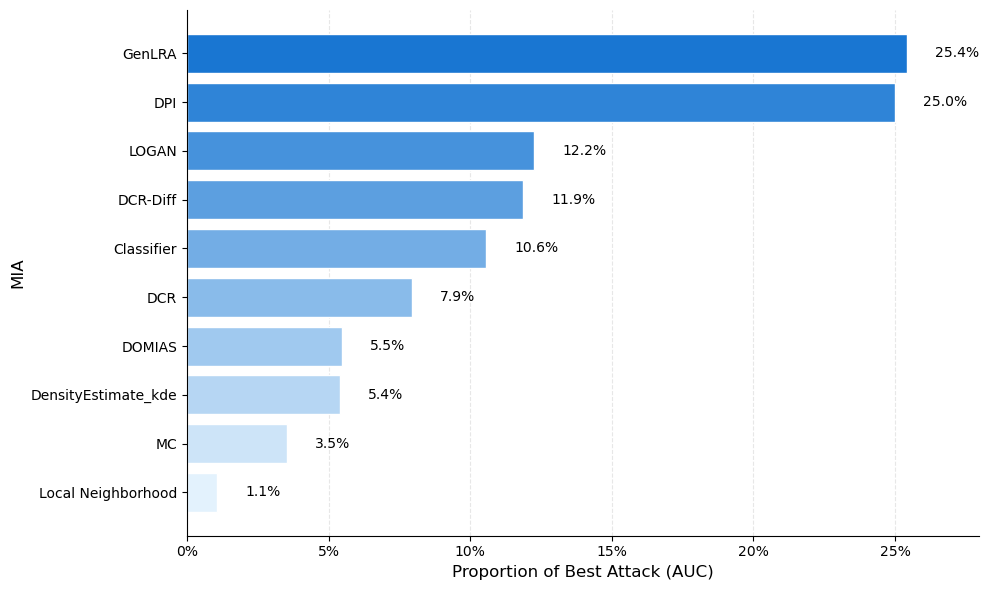

In [316]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

temp = result_df[(result_df['measurement_type'] == 'privacy_auc_roc') & (result_df['synth_ratio'] == 'synth_1x')].copy()

# Create method groups
temp['method_group'] = temp['method_key'].str.extract('(GenLRA|DPI)', expand=False).fillna(temp['method_key'])

# Get max within groups for each experiment run
grouped = temp.groupby(['dataset', 'model', 'seed', 'synth_ratio', 'method_group'])['value'].max().reset_index()

# Rank methods within each run
grouped['rank'] = grouped.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].rank(method='average', ascending=False)

# Find which method(s) got the top rank in each run
grouped['is_top'] = grouped['rank'] == 1

# Proportion of times each method was top
top_proportion = grouped.groupby('method_group')['is_top'].mean()
print(top_proportion)

data = top_proportion
sorted_data = dict(sorted(data.items(), key=lambda x: x[1]))
methods = list(sorted_data.keys())
proportions = list(sorted_data.values())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create light blue gradient colormap
colors = ['#E3F2FD', '#1976D2']  # Light blue to medium blue
n_bars = len(methods)
cmap = LinearSegmentedColormap.from_list('light_blue', colors, N=n_bars)

# Create bars with gradient colors
bars = ax.barh(methods, proportions, 
               color=[cmap(i/max(1, n_bars-1)) for i in range(n_bars)],
               edgecolor='white', linewidth=1)

# Customize the chart
ax.set_xlabel('Proportion of Best Attack (AUC)', fontsize=12)
ax.set_ylabel('MIA', fontsize=12)

# Set x-axis limits and format
ax.set_xlim(0, max(proportions) * 1.1)

# Format x-axis as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))

# Add value labels on bars as percentages
for i, (bar, value) in enumerate(zip(bars, proportions)):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{value*100:.1f}%', ha='left', va='center')

# Improve styling
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('prop_best_AUC.png', dpi=300, bbox_inches='tight')
plt.show()

method_group
Classifier             0.062640
DCR                    0.120246
DCR-Diff               0.128076
DOMIAS                 0.056138
DPI                    0.079978
DensityEstimate_kde    0.095981
GenLRA                 0.252475
LOGAN                  0.097315
Local Neighborhood     0.024049
MC                     0.055928
Name: is_top, dtype: float64


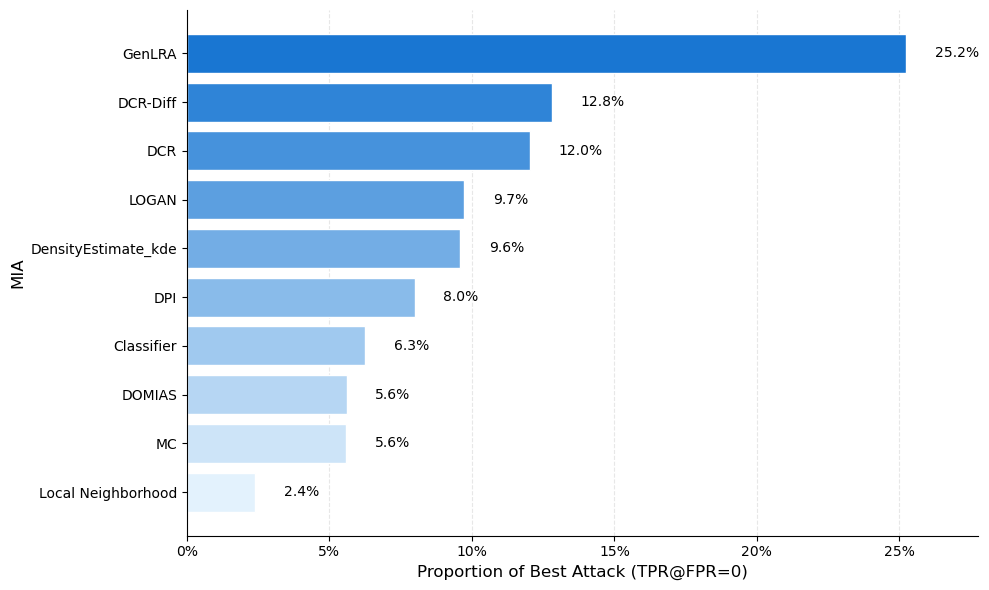

In [343]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

temp = result_df[(result_df['measurement_type'] == 'privacy_tpr_at_fpr_0') & (result_df['synth_ratio'] == 'synth_1x')].copy()

# Create method groups
temp['method_group'] = temp['method_key'].str.extract('(GenLRA|DPI)', expand=False).fillna(temp['method_key'])

# Get max within groups for each experiment run
grouped = temp.groupby(['dataset', 'model', 'seed', 'synth_ratio', 'method_group'])['value'].max().reset_index()

# Rank methods within each run
grouped['rank'] = grouped.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].rank(method='average', ascending=False)

# Find which method(s) got the top rank in each run
grouped['is_top'] = grouped['rank'] == 1

# Proportion of times each method was top
top_proportion = grouped.groupby('method_group')['is_top'].mean()
print(top_proportion)

data = top_proportion
sorted_data = dict(sorted(data.items(), key=lambda x: x[1]))
methods = list(sorted_data.keys())
proportions = list(sorted_data.values())

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create light blue gradient colormap
colors = ['#E3F2FD', '#1976D2']  # Light blue to medium blue
n_bars = len(methods)
cmap = LinearSegmentedColormap.from_list('light_blue', colors, N=n_bars)

# Create bars with gradient colors
bars = ax.barh(methods, proportions, 
               color=[cmap(i/max(1, n_bars-1)) for i in range(n_bars)],
               edgecolor='white', linewidth=1)

# Customize the chart
ax.set_xlabel('Proportion of Best Attack (TPR@FPR=0)', fontsize=12)
ax.set_ylabel('MIA', fontsize=12)

# Set x-axis limits and format
ax.set_xlim(0, max(proportions) * 1.1)

# Format x-axis as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))

# Add value labels on bars as percentages
for i, (bar, value) in enumerate(zip(bars, proportions)):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{value*100:.1f}%', ha='left', va='center')

# Improve styling
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('prop_best_tpr_fpr_0.png', dpi=300, bbox_inches='tight')

plt.show()

In [92]:
measurement_types = ['privacy_auc_roc',  'privacy_tpr_at_fpr_0', 'privacy_tpr_at_fpr_0.001', 'privacy_tpr_at_fpr_0.01',  'privacy_tpr_at_fpr_0.1',]

# Filter for model = 'great' at the beginning
filtered_df = result_df[result_df['model'] != 'great'].copy()

ranking_results = {}
for measurement_type in measurement_types:
    temp = filtered_df[filtered_df['measurement_type'] == measurement_type].copy()
    temp['method_group'] = temp['method_key'].str.extract('(GenLRA|DPI)', expand=False).fillna(temp['method_key'])
    grouped = temp.groupby(['dataset', 'model', 'seed', 'synth_ratio', 'method_group'])['value'].max().reset_index()
    grouped['rank'] = grouped.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].rank(method='average', ascending=False)
    ranking_results[measurement_type] = grouped.groupby('method_group')['rank'].mean()

# Create the final table with means and std devs
ranking_means = {}
ranking_stds = {}
for measurement_type in measurement_types:
    temp = filtered_df[filtered_df['measurement_type'] == measurement_type].copy()
    temp['method_group'] = temp['method_key'].str.extract('(GenLRA|DPI)', expand=False).fillna(temp['method_key'])
    grouped = temp.groupby(['dataset', 'model', 'seed', 'synth_ratio', 'method_group'])['value'].max().reset_index()
    grouped['rank'] = grouped.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].rank(method='average', ascending=False)
    ranking_means[measurement_type] = grouped.groupby('method_group')['rank'].mean()
    ranking_stds[measurement_type] = grouped.groupby('method_group')['rank'].std()

# Create combined table with mean (std) format
ranking_table = pd.DataFrame(ranking_means)
std_table = pd.DataFrame(ranking_stds)

# Format as mean (std) rounded to 2 decimal places
for col in ranking_table.columns:
    ranking_table[col] = ranking_table[col].round(2).astype(str) + ' (' + std_table[col].round(2).astype(str) + ')'

# Generate LaTeX table
latex_table = ranking_table.to_latex(escape=False)
print(latex_table)

\begin{tabular}{llllll}
\toprule
 & privacy_auc_roc & privacy_tpr_at_fpr_0 & privacy_tpr_at_fpr_0.001 & privacy_tpr_at_fpr_0.01 & privacy_tpr_at_fpr_0.1 \\
method_group &  &  &  &  &  \\
\midrule
Classifier & 4.92 (2.78) & 6.13 (2.5) & 5.8 (2.6) & 5.43 (2.63) & 5.38 (2.71) \\
DCR & 5.05 (2.52) & 5.06 (2.66) & 5.13 (2.8) & 5.04 (2.72) & 5.14 (2.6) \\
DCR-Diff & 4.68 (2.68) & 4.27 (2.39) & 4.6 (2.71) & 4.65 (2.85) & 4.68 (2.84) \\
DOMIAS & 5.22 (2.45) & 4.66 (2.31) & 4.93 (2.65) & 5.52 (2.89) & 5.55 (2.85) \\
DPI & 3.5 (2.28) & 6.36 (2.55) & 5.26 (2.47) & 4.25 (2.27) & 3.72 (2.26) \\
DensityEstimate_kde & 5.84 (2.67) & 4.67 (2.42) & 5.01 (2.7) & 5.35 (2.72) & 5.53 (2.62) \\
GenLRA & 3.99 (2.64) & 3.76 (2.74) & 3.66 (2.58) & 3.8 (2.61) & 3.73 (2.59) \\
LOGAN & 6.32 (3.26) & 5.11 (2.57) & 5.6 (2.95) & 6.08 (2.97) & 6.15 (3.0) \\
Local Neighborhood & 6.45 (2.18) & 6.27 (2.36) & 6.13 (2.46) & 6.02 (2.42) & 6.11 (2.24) \\
MC & 5.99 (2.43) & 5.36 (2.35) & 5.6 (2.63) & 5.8 (2.55) & 5.95 (2.6) \

In [91]:
ranking_table

,privacy_tpr_at_fpr_0.1,privacy_tpr_at_fpr_0.01,privacy_tpr_at_fpr_0.001,privacy_tpr_at_fpr_0,privacy_auc_roc
method_group,,,,,
Classifier,5.38 (2.71),5.43 (2.63),5.8 (2.6),6.13 (2.5),4.92 (2.78)
DCR,5.14 (2.6),5.04 (2.72),5.13 (2.8),5.06 (2.66),5.05 (2.52)
DCR-Diff,4.68 (2.84),4.65 (2.85),4.6 (2.71),4.27 (2.39),4.68 (2.68)
DOMIAS,5.55 (2.85),5.52 (2.89),4.93 (2.65),4.66 (2.31),5.22 (2.45)
DPI,3.72 (2.26),4.25 (2.27),5.26 (2.47),6.36 (2.55),3.5 (2.28)
DensityEstimate_kde,5.53 (2.62),5.35 (2.72),5.01 (2.7),4.67 (2.42),5.84 (2.67)
GenLRA,3.73 (2.59),3.8 (2.61),3.66 (2.58),3.76 (2.74),3.99 (2.64)
LOGAN,6.15 (3.0),6.08 (2.97),5.6 (2.95),5.11 (2.57),6.32 (3.26)
Local Neighborhood,6.11 (2.24),6.02 (2.42),6.13 (2.46),6.27 (2.36),6.45 (2.18)


# Figure Utility

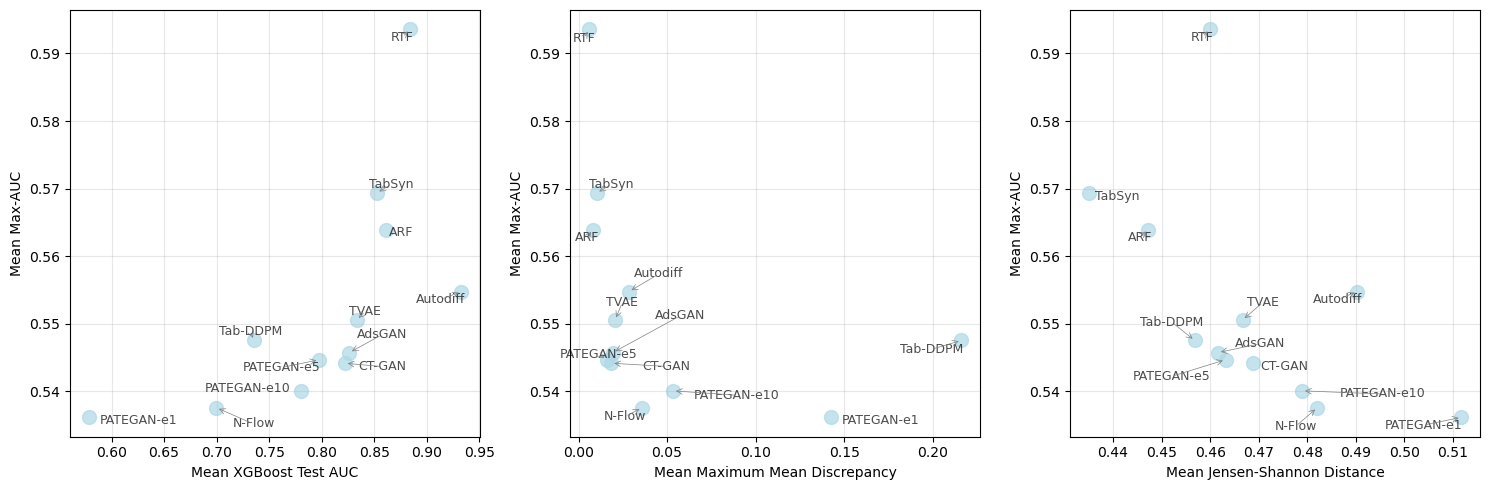

Correlation coefficients with Privacy AUC ROC:


ValueError: data type <class 'numpy.object_'> not inexact

In [122]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text  # Import adjustText library
from scipy.stats import pearsonr

model_name_mapping = {
    "pategan": "PATEGAN-e1",
    "pategan_e5": "PATEGAN-e5",
    "pategan_e10": "PATEGAN-e10",
    "nflow": "N-Flow",
    "ddpm": "Tab-DDPM",
    "ctgan": "CT-GAN",
    "tvae": "TVAE",
    "adsgan": "AdsGAN",
    "autodiff": "Autodiff",
    "tabsyn": "TabSyn",  # Fixed: removed "and" prefix
    "rtf": "RTF",
    "arf": "ARF"
}

# Your actual data calculations
privacy_auc_roc = result_df[(result_df['measurement_type'] == 'privacy_auc_roc') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
utility_test_auc = result_df[(result_df['measurement_type'] == 'utility_test_auc') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_rbf_mmd = result_df[(result_df['measurement_type'] == 'statistical_rbf_mmd') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_js_distance = result_df[(result_df['measurement_type'] == 'statistical_js_distance') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()

# Get model names from the index and filter out unwanted models
models = privacy_auc_roc.index.tolist()
models_to_filter = ['great']
models = [model for model in models if model not in models_to_filter]

# Filter the data series to only include the filtered models
privacy_auc_roc = privacy_auc_roc[models]
utility_test_auc = utility_test_auc[models]
statistical_rbf_mmd = statistical_rbf_mmd[models]
statistical_js_distance = statistical_js_distance[models]

# Create the plot with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fixed function to add annotations with adjusted positions
def add_annotations(ax, x_data, y_data, original_models):
    texts = []
    for model in original_models:
        # Use original model name for data access, mapped name for display
        display_name = model_name_mapping.get(model, model)
        texts.append(ax.text(x_data[model], y_data[model], display_name, 
                           fontsize=9, ha='center', va='center', alpha=0.7))
    
    # Adjust the label positions to avoid overlap with each other and the points
    adjust_text(texts, ax=ax, only_move={'points': 'xy', 'text': 'xy'}, 
                arrowprops=dict(arrowstyle="->", color='gray', lw=0.5), 
                force_text=1.9, expand_text=(3, 3))

# Subplot 1: Privacy vs Utility
axes[0].scatter(utility_test_auc, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[0], utility_test_auc, privacy_auc_roc, models)  # Use original model names
axes[0].set_xlabel('Mean XGBoost Test AUC')
axes[0].set_ylabel('Mean Max-AUC')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Privacy vs RBF MMD
axes[1].scatter(statistical_rbf_mmd, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[1], statistical_rbf_mmd, privacy_auc_roc, models)  # Use original model names
axes[1].set_xlabel('Mean Maximum Mean Discrepancy')  # Fixed typo
axes[1].set_ylabel('Mean Max-AUC')
axes[1].grid(True, alpha=0.3)

# Subplot 3: Privacy vs JS Distance
axes[2].scatter(statistical_js_distance, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[2], statistical_js_distance, privacy_auc_roc, models)  # Use original model names
axes[2].set_xlabel('Mean Jensen-Shannon Distance')  # Fixed typo
axes[2].set_ylabel('Mean Max-AUC')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('AUC_utility.png', dpi=300, bbox_inches='tight')

plt.show()
print("Correlation coefficients with Privacy AUC ROC:")

# Calculate correlation and p-value for Utility Test AUC
corr_utility, p_utility = pearsonr(privacy_auc_roc, utility_test_auc)
print(f"Utility Test AUC: {corr_utility:.3f} (p-value: {p_utility:.3f})")

# Calculate correlation and p-value for Statistical RBF MMD
corr_rbf, p_rbf = pearsonr(privacy_auc_roc, statistical_rbf_mmd)
print(f"Statistical RBF MMD: {corr_rbf:.3f} (p-value: {p_rbf:.3f})")

# Calculate correlation and p-value for Statistical JS Distance
corr_js, p_js = pearsonr(privacy_auc_roc, statistical_js_distance)
print(f"Statistical JS Distance: {corr_js:.3f} (p-value: {p_js:.3f})")

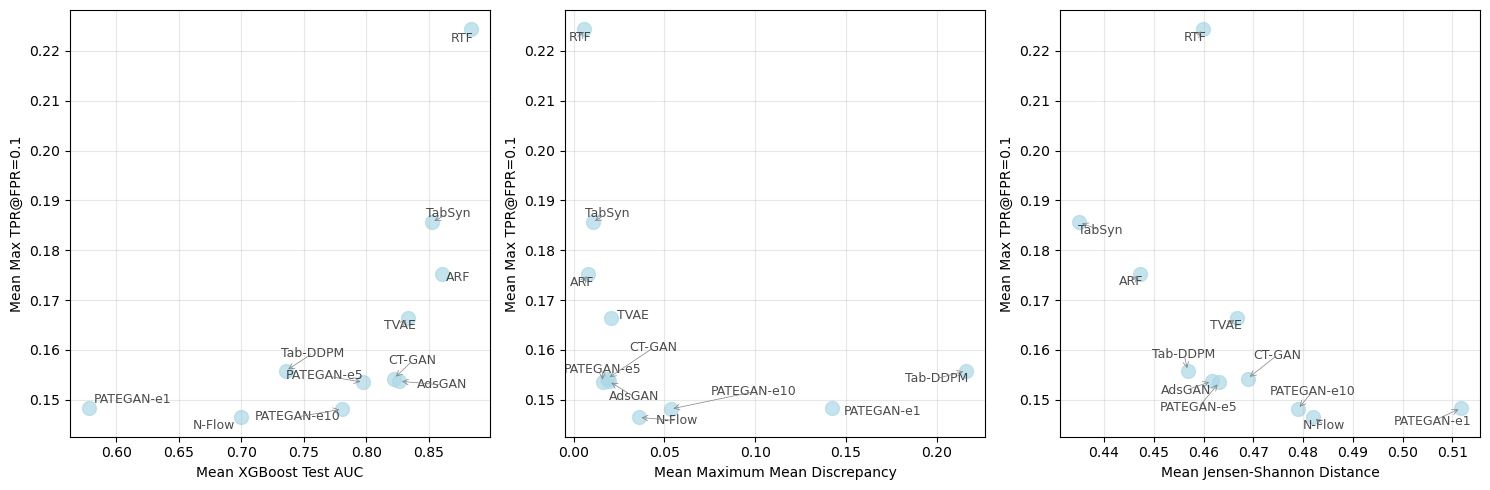

Correlation coefficients with Privacy AUC ROC:
Utility Test AUC: 0.616
Statistical RBF MMD: -0.363
Statistical JS Distance: -0.503


In [337]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text  # Import adjustText library

model_name_mapping = {
    "pategan": "PATEGAN-e1",
    "pategan_e5": "PATEGAN-e5",
    "pategan_e10": "PATEGAN-e10",
    "nflow": "N-Flow",
    "ddpm": "Tab-DDPM",
    "ctgan": "CT-GAN",
    "tvae": "TVAE",
    "adsgan": "AdsGAN",
    "autodiff": "Autodiff",
    "tabsyn": "TabSyn",  # Fixed: removed "and" prefix
    "rtf": "RTF",
    "arf": "ARF"
}

# Your actual data calculations
privacy_auc_roc = result_df[(result_df['measurement_type'] == 'privacy_tpr_at_fpr_0.1') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
utility_test_auc = result_df[(result_df['measurement_type'] == 'utility_test_auc') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_rbf_mmd = result_df[(result_df['measurement_type'] == 'statistical_rbf_mmd') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_js_distance = result_df[(result_df['measurement_type'] == 'statistical_js_distance') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()

# Get model names from the index and filter out unwanted models
models = privacy_auc_roc.index.tolist()
models_to_filter = ['great','autodiff']
models = [model for model in models if model not in models_to_filter]

# Filter the data series to only include the filtered models
privacy_auc_roc = privacy_auc_roc[models]
utility_test_auc = utility_test_auc[models]
statistical_rbf_mmd = statistical_rbf_mmd[models]
statistical_js_distance = statistical_js_distance[models]

# Create the plot with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fixed function to add annotations with adjusted positions
def add_annotations(ax, x_data, y_data, original_models):
    texts = []
    for model in original_models:
        # Use original model name for data access, mapped name for display
        display_name = model_name_mapping.get(model, model)
        texts.append(ax.text(x_data[model], y_data[model], display_name, 
                           fontsize=9, ha='center', va='center', alpha=0.7))
    
    # Adjust the label positions to avoid overlap with each other and the points
    adjust_text(texts, ax=ax, only_move={'points': 'xy', 'text': 'xy'}, 
                arrowprops=dict(arrowstyle="->", color='gray', lw=0.5), 
                force_text=1.9, expand_text=(3, 3))

# Subplot 1: Privacy vs Utility
axes[0].scatter(utility_test_auc, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[0], utility_test_auc, privacy_auc_roc, models)  # Use original model names
axes[0].set_xlabel('Mean XGBoost Test AUC')
axes[0].set_ylabel('Mean Max TPR@FPR=0.1')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Privacy vs RBF MMD
axes[1].scatter(statistical_rbf_mmd, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[1], statistical_rbf_mmd, privacy_auc_roc, models)  # Use original model names
axes[1].set_xlabel('Mean Maximum Mean Discrepancy')  # Fixed typo
axes[1].set_ylabel('Mean Max TPR@FPR=0.1')
axes[1].grid(True, alpha=0.3)

# Subplot 3: Privacy vs JS Distance
axes[2].scatter(statistical_js_distance, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[2], statistical_js_distance, privacy_auc_roc, models)  # Use original model names
axes[2].set_xlabel('Mean Jensen-Shannon Distance')  # Fixed typo
axes[2].set_ylabel('Mean Max TPR@FPR=0.1')
axes[2].grid(True, alpha=0.3)
plt.savefig('tpr_01_utility.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Optional: Print the correlation coefficients
print("Correlation coefficients with Privacy AUC ROC:")
print(f"Utility Test AUC: {privacy_auc_roc.corr(utility_test_auc):.3f}")
print(f"Statistical RBF MMD: {privacy_auc_roc.corr(statistical_rbf_mmd):.3f}")
print(f"Statistical JS Distance: {privacy_auc_roc.corr(statistical_js_distance):.3f}")

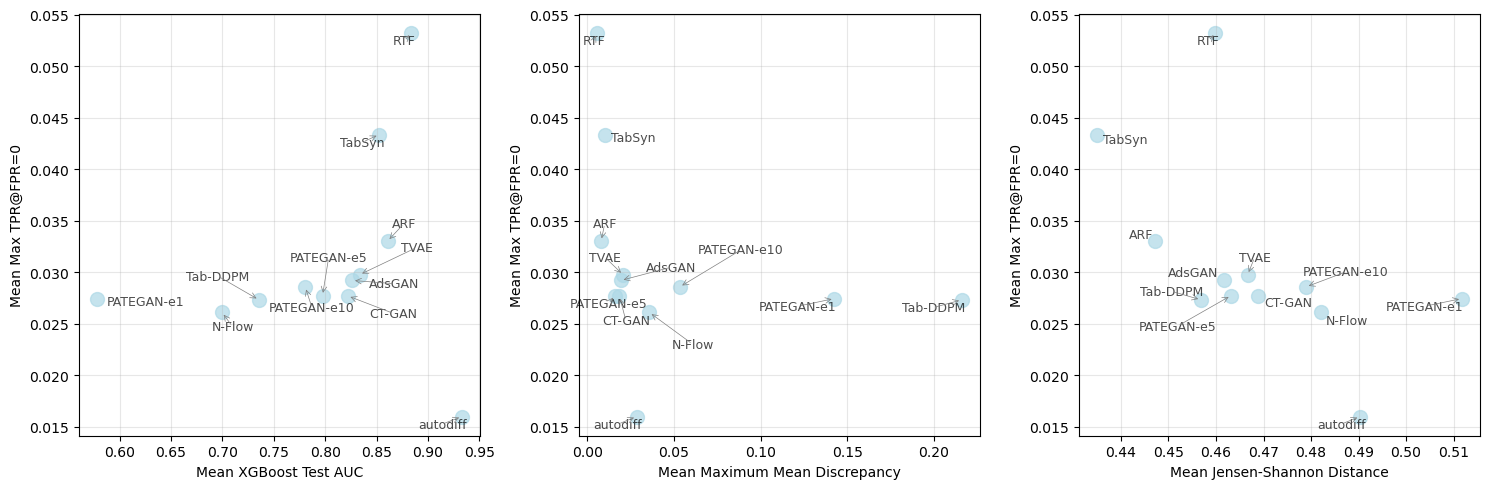

Correlation coefficients with Privacy AUC ROC:
Utility Test AUC: 0.212
Statistical RBF MMD: -0.273
Statistical JS Distance: -0.553


In [338]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text  # Import adjustText library

model_name_mapping = {
    "pategan": "PATEGAN-e1",
    "pategan_e5": "PATEGAN-e5",
    "pategan_e10": "PATEGAN-e10",
    "nflow": "N-Flow",
    "ddpm": "Tab-DDPM",
    "ctgan": "CT-GAN",
    "tvae": "TVAE",
    "adsgan": "AdsGAN",
    "tabsyn": "TabSyn",  # Fixed: removed "and" prefix
    "rtf": "RTF",
    "arf": "ARF"
}

# Your actual data calculations
privacy_auc_roc = result_df[(result_df['measurement_type'] == 'privacy_tpr_at_fpr_0') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
utility_test_auc = result_df[(result_df['measurement_type'] == 'utility_test_auc') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_rbf_mmd = result_df[(result_df['measurement_type'] == 'statistical_rbf_mmd') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_js_distance = result_df[(result_df['measurement_type'] == 'statistical_js_distance') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()

# Get model names from the index and filter out unwanted models
models = privacy_auc_roc.index.tolist()
models_to_filter = ['great']
models = [model for model in models if model not in models_to_filter]

# Filter the data series to only include the filtered models
privacy_auc_roc = privacy_auc_roc[models]
utility_test_auc = utility_test_auc[models]
statistical_rbf_mmd = statistical_rbf_mmd[models]
statistical_js_distance = statistical_js_distance[models]

# Create the plot with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fixed function to add annotations with adjusted positions
def add_annotations(ax, x_data, y_data, original_models):
    texts = []
    for model in original_models:
        # Use original model name for data access, mapped name for display
        display_name = model_name_mapping.get(model, model)
        texts.append(ax.text(x_data[model], y_data[model], display_name, 
                           fontsize=9, ha='center', va='center', alpha=0.7))
    
    # Adjust the label positions to avoid overlap with each other and the points
    adjust_text(texts, ax=ax, only_move={'points': 'xy', 'text': 'xy'}, 
                arrowprops=dict(arrowstyle="->", color='gray', lw=0.5), 
                force_text=1.9, expand_text=(3, 3))

# Subplot 1: Privacy vs Utility
axes[0].scatter(utility_test_auc, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[0], utility_test_auc, privacy_auc_roc, models)  # Use original model names
axes[0].set_xlabel('Mean XGBoost Test AUC')
axes[0].set_ylabel('Mean Max TPR@FPR=0')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Privacy vs RBF MMD
axes[1].scatter(statistical_rbf_mmd, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[1], statistical_rbf_mmd, privacy_auc_roc, models)  # Use original model names
axes[1].set_xlabel('Mean Maximum Mean Discrepancy')  # Fixed typo
axes[1].set_ylabel('Mean Max TPR@FPR=0')
axes[1].grid(True, alpha=0.3)

# Subplot 3: Privacy vs JS Distance
axes[2].scatter(statistical_js_distance, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[2], statistical_js_distance, privacy_auc_roc, models)  # Use original model names
axes[2].set_xlabel('Mean Jensen-Shannon Distance')  # Fixed typo
axes[2].set_ylabel('Mean Max TPR@FPR=0')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tpr_0_utility.png', dpi=300, bbox_inches='tight')

plt.show()

# Optional: Print the correlation coefficients
print("Correlation coefficients with Privacy AUC ROC:")
print(f"Utility Test AUC: {privacy_auc_roc.corr(utility_test_auc):.3f}")
print(f"Statistical RBF MMD: {privacy_auc_roc.corr(statistical_rbf_mmd):.3f}")
print(f"Statistical JS Distance: {privacy_auc_roc.corr(statistical_js_distance):.3f}")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text  # Import adjustText library

model_name_mapping = {
    "pategan": "PATEGAN-e1",
    "pategan_e5": "PATEGAN-e5",
    "pategan_e10": "PATEGAN-e10",
    "nflow": "N-Flow",
    "ddpm": "Tab-DDPM",
    "ctgan": "CT-GAN",
    "tvae": "TVAE",
    "adsgan": "AdsGAN",
    "tabsyn": "TabSyn",  # Fixed: removed "and" prefix
    "rtf": "RTF",
    "arf": "ARF"
}

# Your actual data calculations
privacy_auc_roc = result_df[(result_df['measurement_type'] == 'privacy_tpr_at_fpr_0') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
utility_test_auc = result_df[(result_df['measurement_type'] == 'utility_test_auc') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_rbf_mmd = result_df[(result_df['measurement_type'] == 'statistical_rbf_mmd') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()
statistical_js_distance = result_df[(result_df['measurement_type'] == 'statistical_js_distance') & (result_df['synth_ratio'] == 'synth_1x')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().groupby(['model']).mean()

# Get model names from the index and filter out unwanted models
models = privacy_auc_roc.index.tolist()
models_to_filter = ['great']
models = [model for model in models if model not in models_to_filter]

# Filter the data series to only include the filtered models
privacy_auc_roc = privacy_auc_roc[models]
utility_test_auc = utility_test_auc[models]
statistical_rbf_mmd = statistical_rbf_mmd[models]
statistical_js_distance = statistical_js_distance[models]

# Create the plot with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fixed function to add annotations with adjusted positions
def add_annotations(ax, x_data, y_data, original_models):
    texts = []
    for model in original_models:
        # Use original model name for data access, mapped name for display
        display_name = model_name_mapping.get(model, model)
        texts.append(ax.text(x_data[model], y_data[model], display_name, 
                           fontsize=9, ha='center', va='center', alpha=0.7))
    
    # Adjust the label positions to avoid overlap with each other and the points
    adjust_text(texts, ax=ax, only_move={'points': 'xy', 'text': 'xy'}, 
                arrowprops=dict(arrowstyle="->", color='gray', lw=0.5), 
                force_text=1.9, expand_text=(3, 3))

# Subplot 1: Privacy vs Utility
axes[0].scatter(utility_test_auc, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[0], utility_test_auc, privacy_auc_roc, models)  # Use original model names
axes[0].set_xlabel('Mean XGBoost Test AUC')
axes[0].set_ylabel('Mean Max TPR@FPR=0')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Privacy vs RBF MMD
axes[1].scatter(statistical_rbf_mmd, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[1], statistical_rbf_mmd, privacy_auc_roc, models)  # Use original model names
axes[1].set_xlabel('Mean Maximum Mean Discrepancy')  # Fixed typo
axes[1].set_ylabel('Mean Max TPR@FPR=0')
axes[1].grid(True, alpha=0.3)

# Subplot 3: Privacy vs JS Distance
axes[2].scatter(statistical_js_distance, privacy_auc_roc, s=100, alpha=0.7, color='lightblue')
add_annotations(axes[2], statistical_js_distance, privacy_auc_roc, models)  # Use original model names
axes[2].set_xlabel('Mean Jensen-Shannon Distance')  # Fixed typo
axes[2].set_ylabel('Mean Max TPR@FPR=0')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: Print the correlation coefficients
print("Correlation coefficients with Privacy AUC ROC:")
print(f"Utility Test AUC: {privacy_auc_roc.corr(utility_test_auc):.3f}")
print(f"Statistical RBF MMD: {privacy_auc_roc.corr(statistical_rbf_mmd):.3f}")
print(f"Statistical JS Distance: {privacy_auc_roc.corr(statistical_js_distance):.3f}")

In [102]:
import scipy.stats as stats
import pandas as pd
import numpy as np

# Convert to numeric, forcing errors to NaN
privacy_auc_roc = pd.to_numeric(privacy_auc_roc, errors='coerce')
utility_test_auc = pd.to_numeric(statistical_rbf_mmd, errors='coerce')

# Assuming privacy_auc_roc and utility_test_auc are your two arrays or pandas series
corr, p_value = stats.pearsonr(np.array(privacy_auc_roc), np.array(utility_test_auc))

print(f"Correlation: {corr}")
print(f"P-value: {p_value}")


Correlation: -0.37651826403078986
P-value: 0.22767732348958106


In [98]:
np(utility_test_auc)

pandas.core.series.Series

In [97]:
privacy_auc_roc

model
adsgan         0.545744
arf            0.563942
autodiff       0.554762
ctgan          0.544164
ddpm           0.547534
nflow          0.537594
pategan        0.536163
pategan_e10    0.540083
pategan_e5     0.544683
rtf            0.593553
tabsyn         0.569361
tvae           0.550556
Name: value, dtype: object

In [156]:
measurement_types = ['privacy_auc_roc',  'privacy_tpr_at_fpr_0', 'privacy_tpr_at_fpr_0.001', 'privacy_tpr_at_fpr_0.01',  'privacy_tpr_at_fpr_0.1',]

# Filter for model != 'great' and synth_ratio = 'synth_1x'
filtered_df = result_df[(result_df['model'] != 'great') & (result_df['synth_ratio'] == 'synth_1x')].copy()

# Create the final table with means and std devs
value_means = {}
value_stds = {}

for measurement_type in measurement_types:
    temp = filtered_df[filtered_df['measurement_type'] == measurement_type].copy()
    
    # Group and take max value for each combination, then calculate mean and std of values
    grouped = temp.groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max().reset_index()
    
    # Calculate mean and std of the actual values grouped by model (no rounding here yet)
    value_means[measurement_type] = grouped.groupby('model')['value'].mean()
    value_stds[measurement_type] = grouped.groupby('model')['value'].std()

# Create combined table with mean (std) format
value_table = pd.DataFrame(value_means)
std_table = pd.DataFrame(value_stds)

# Format as mean (std) rounded to 2 decimal places
for col in value_table.columns:
    means_rounded = value_table[col].round(3)
    stds_rounded = std_table[col].round(3)
    value_table[col] = means_rounded.apply(lambda x: f"{x:.3f}") + ' (' + stds_rounded.apply(lambda x: f"{x:.3f}") + ')'

# Generate LaTeX table
latex_table = value_table.to_latex(escape=False)
print(latex_table)

\begin{tabular}{llllll}
\toprule
 & privacy_auc_roc & privacy_tpr_at_fpr_0 & privacy_tpr_at_fpr_0.001 & privacy_tpr_at_fpr_0.01 & privacy_tpr_at_fpr_0.1 \\
model &  &  &  &  &  \\
\midrule
adsgan & 0.546 (0.035) & 0.029 (0.051) & 0.030 (0.051) & 0.041 (0.048) & 0.154 (0.041) \\
arf & 0.564 (0.041) & 0.033 (0.063) & 0.034 (0.063) & 0.048 (0.061) & 0.175 (0.055) \\
autodiff & 0.555 (nan) & 0.016 (nan) & 0.016 (nan) & 0.045 (nan) & 0.234 (nan) \\
ctgan & 0.544 (0.032) & 0.028 (0.049) & 0.028 (0.049) & 0.039 (0.047) & 0.154 (0.043) \\
ddpm & 0.548 (0.042) & 0.027 (0.049) & 0.028 (0.048) & 0.039 (0.046) & 0.156 (0.047) \\
nflow & 0.538 (0.027) & 0.026 (0.046) & 0.027 (0.046) & 0.037 (0.044) & 0.146 (0.035) \\
pategan & 0.536 (0.035) & 0.027 (0.063) & 0.028 (0.063) & 0.038 (0.061) & 0.148 (0.056) \\
pategan_e10 & 0.540 (0.036) & 0.029 (0.060) & 0.029 (0.060) & 0.040 (0.058) & 0.148 (0.050) \\
pategan_e5 & 0.545 (0.036) & 0.028 (0.059) & 0.028 (0.058) & 0.039 (0.056) & 0.153 (0.050) \\
rtf & 

In [326]:
import json
import pandas as pd
from pathlib import Path

# Method 3: Dictionary merging (for object-style JSON)
def union_json_objects(file_paths):
    combined_data = {}
    
    for file_path in file_paths:
        with open(file_path, 'r') as f:
            data = json.load(f)
            combined_data.update(data)  # Merge dictionaries
    
    return combined_data

# Usage example
file_paths = ['experiment_logs/experiment_20250830_211854/results.json']


# For tabular data
combined = union_json_objects(file_paths)
combined_df_dcr= pd.DataFrame(combined).T


In [327]:
result_dcr_df = flatten_results_to_dataframe(combined_df_dcr, 'results')
result_dcr_df[['dataset', 'model', 'seed', 'synth_ratio']] = result_dcr_df['index'].str.split('/', expand=True)

In [328]:
parsed_values = result_dcr_df[result_dcr_df['measurement_type']=='statistical_dcr_results']['value']


In [329]:
filtered_dcr_df = result_dcr_df[result_dcr_df['measurement_type']=='statistical_dcr_results'].copy()
filtered_dcr_df['dcr_proportion'] = filtered_dcr_df['value'].apply(lambda x: x['dcr_proportion'])
dcr_data = filtered_dcr_df[['dataset', 'model', 'seed', 'synth_ratio', 'dcr_proportion']]

In [330]:
# Calculate mean and std
dcr_mean = dcr_data.groupby(['model'])['dcr_proportion'].mean()
dcr_std = dcr_data.groupby(['model'])['dcr_proportion'].std()

# Combine into LaTeX format: mean (std) rounded to 3 decimal places
dcr_formatted = dcr_mean.round(3).astype(str) + ' (' + dcr_std.round(3).astype(str) + ')'

print("LaTeX formatted results:")
for model, result in dcr_formatted.items():
    print(f"{model}: {result}")

# Alternative: Create a more complete LaTeX table format
print("\nAs LaTeX table rows:")
for model, result in dcr_formatted.items():
    print(f"{model} & {result} \\\\")

# Or as a pandas Series for further use
print("\nAs pandas Series:")
print(dcr_formatted)

LaTeX formatted results:
adsgan: 0.787 (0.069)
arf: 0.805 (0.061)
autodiff: 0.786 (nan)
ctgan: 0.785 (0.068)
ddpm: 0.782 (0.081)
great: 0.796 (0.044)
nflow: 0.778 (0.065)
pategan: 0.776 (0.122)
rtf: 0.825 (0.094)
tabsyn: 0.808 (0.095)
tvae: 0.802 (0.079)

As LaTeX table rows:
adsgan & 0.787 (0.069) \\
arf & 0.805 (0.061) \\
autodiff & 0.786 (nan) \\
ctgan & 0.785 (0.068) \\
ddpm & 0.782 (0.081) \\
great & 0.796 (0.044) \\
nflow & 0.778 (0.065) \\
pategan & 0.776 (0.122) \\
rtf & 0.825 (0.094) \\
tabsyn & 0.808 (0.095) \\
tvae & 0.802 (0.079) \\

As pandas Series:
model
adsgan      0.787 (0.069)
arf         0.805 (0.061)
autodiff      0.786 (nan)
ctgan       0.785 (0.068)
ddpm        0.782 (0.081)
great       0.796 (0.044)
nflow       0.778 (0.065)
pategan     0.776 (0.122)
rtf         0.825 (0.094)
tabsyn      0.808 (0.095)
tvae        0.802 (0.079)
Name: dcr_proportion, dtype: object


In [334]:
privacy_auc_roc = result_df[(result_df['measurement_type'] == 'privacy_auc_roc') & (result_df['model'] != 'great') & (result_df['model'] != 'autodiff')].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max()
merged_df.size

25400

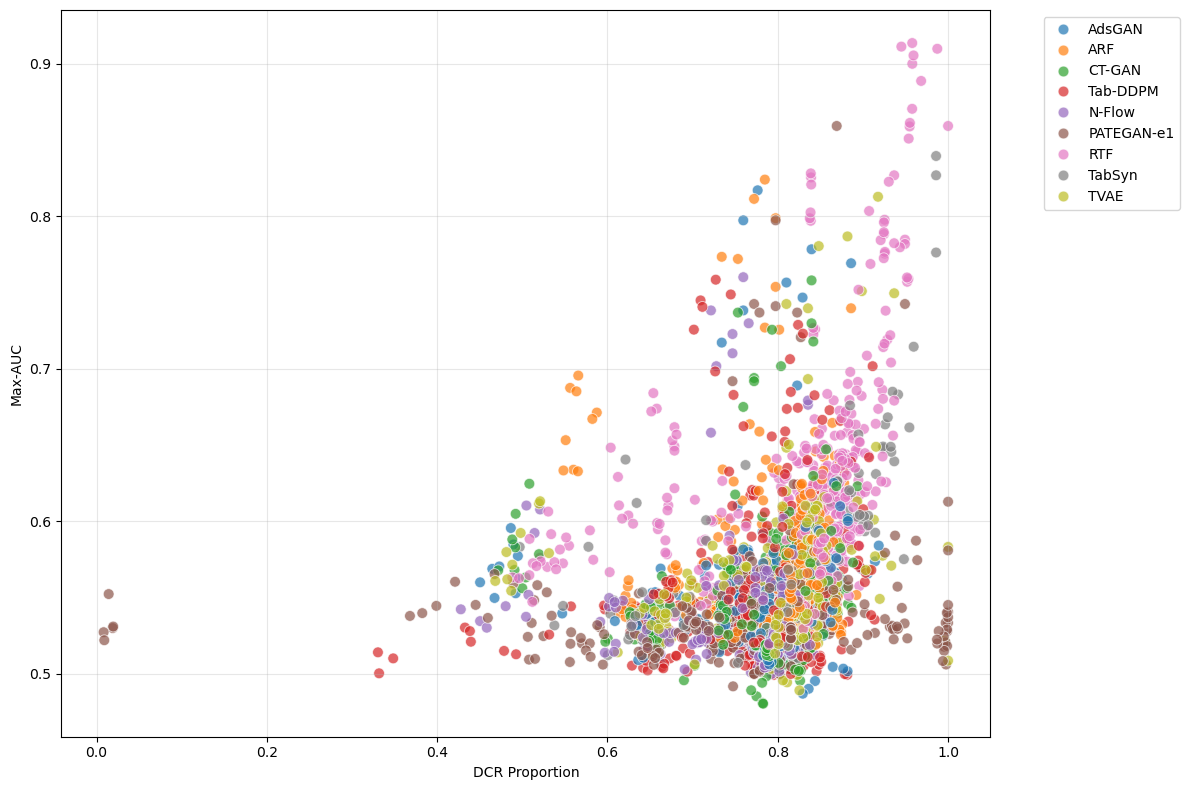

Correlation between Privacy TPR and DCR Proportion: 0.225

Summary by Model:
                  value              dcr_proportion       
                   mean    std count           mean    std
model_display                                             
ARF            0.568897  0.043   441          0.805  0.061
AdsGAN         0.545849  0.038   435          0.787  0.068
CT-GAN         0.544647  0.036   432          0.784  0.067
N-Flow         0.537723  0.031   420          0.778  0.066
PATEGAN-e1     0.536671  0.037   435          0.774  0.130
RTF            0.615714  0.077   453          0.825  0.094
TVAE           0.554483  0.038   435          0.802  0.072
Tab-DDPM       0.549221  0.045   432          0.783  0.080
TabSyn         0.569361  0.057   144          0.808  0.095


In [336]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model name mapping
model_name_mapping = {
    "pategan": "PATEGAN-e1",
    "pategan_e5": "PATEGAN-e5",
    "pategan_e10": "PATEGAN-e10",
    "nflow": "N-Flow",
    "ddpm": "Tab-DDPM",
    "ctgan": "CT-GAN",
    "tvae": "TVAE",
    "adsgan": "AdsGAN",
    "tabsyn": "TabSyn",
    "rtf": "RTF",
    "arf": "ARF"
}

# Method 2: Reset index and merge on columns
merged_df = privacy_auc_roc.reset_index().merge(
    dcr_data.reset_index(),
    on=['dataset', 'model', 'seed', 'synth_ratio'],
    how='inner'
)

# Apply model name mapping
merged_df['model_display'] = merged_df['model'].map(model_name_mapping).fillna(merged_df['model'])

# Enhanced scatter plot with seaborn using mapped model names
plt.figure(figsize=(12, 8))
# Create scatter plot with seaborn using the mapped model names
sns.scatterplot(data=merged_df.reset_index(), 
                x='dcr_proportion', 
                y='value',
                hue='model_display',  # Use mapped model names for legend
                alpha=0.7,
                s=60)
plt.xlabel('DCR Proportion')
plt.ylabel('Max-AUC')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside plot area
plt.tight_layout()
plt.savefig('DCR.png', dpi=300, bbox_inches='tight')

plt.show()

# Print correlation
correlation = merged_df['value'].corr(merged_df['dcr_proportion'])
print(f"Correlation between Privacy TPR and DCR Proportion: {correlation:.3f}")

# Optional: Print summary statistics by model
print("\nSummary by Model:")
summary_stats = merged_df.groupby('model_display').agg({
    'value': ['mean', 'std', 'count'],
    'dcr_proportion': ['mean', 'std']
}).round(3)
print(summary_stats)

In [272]:
import pandas as pd
import numpy as np

# Define the parameters
models_of_interest = ['pategan', 'pategan_e5', 'pategan_e10']
synth_ratio_value = 'synth_1x'
measurement_types = ['privacy_auc_roc', 'privacy_tpr_at_fpr_0', 'privacy_tpr_at_fpr_0.001', 'privacy_tpr_at_fpr_0.01', 'privacy_tpr_at_fpr_0.1']

# Initialize results dictionary
results_table = []

# Process each measurement type
for measurement_type in measurement_types:
    print(f"\nProcessing {measurement_type}...")
    
    # Get data for this measurement type
    measurement_data = result_df[(result_df['measurement_type'] == measurement_type)].groupby(['dataset', 'model', 'seed', 'synth_ratio'])['value'].max()
    
    # Filter for specified models and synth_ratio
    filtered_data = measurement_data[
        (measurement_data.index.get_level_values('model').isin(models_of_interest)) &
        (measurement_data.index.get_level_values('synth_ratio') == synth_ratio_value)
    ]
    
    # Convert to numeric
    filtered_data_numeric = pd.to_numeric(filtered_data, errors='coerce').dropna()
    
    # Calculate statistics for each model
    for model in models_of_interest:
        model_data = filtered_data_numeric[filtered_data_numeric.index.get_level_values('model') == model]
        
        if len(model_data) >= 10:
            top_10 = model_data.nlargest(10)
            mean_top_10 = top_10.mean()
            std_top_10 = top_10.std()
            n_values = len(model_data)
        elif len(model_data) > 0:
            # Use all available values if less than 10
            mean_top_10 = model_data.mean()
            std_top_10 = model_data.std()
            n_values = len(model_data)
        else:
            # No data available
            mean_top_10 = np.nan
            std_top_10 = np.nan
            n_values = 0
        
        # Add to results
        results_table.append({
            'measurement_type': measurement_type,
            'model': model,
            'mean_top_10': mean_top_10,
            'std_top_10': std_top_10,
            'total_entries': n_values
        })

# Create DataFrame from results
results_df = pd.DataFrame(results_table)

# Pivot to create a nice table format
mean_table = results_df.pivot(index='measurement_type', columns='model', values='mean_top_10')
std_table = results_df.pivot(index='measurement_type', columns='model', values='std_top_10')
count_table = results_df.pivot(index='measurement_type', columns='model', values='total_entries')

print("\n" + "="*80)
print("MEAN OF TOP 10 VALUES BY MEASUREMENT TYPE AND MODEL")
print("="*80)
print(mean_table.round(4))

print("\n" + "="*80)
print("STANDARD DEVIATION OF TOP 10 VALUES BY MEASUREMENT TYPE AND MODEL")
print("="*80)
print(std_table.round(4))

print("\n" + "="*80)
print("TOTAL NUMBER OF ENTRIES BY MEASUREMENT TYPE AND MODEL")
print("="*80)
print(count_table)

# Create a combined table with mean ± std format
print("\n" + "="*80)
print("COMBINED TABLE: MEAN ± STD")
print("="*80)

combined_table = pd.DataFrame(index=measurement_types, columns=models_of_interest)
for measurement_type in measurement_types:
    for model in models_of_interest:
        mean_val = mean_table.loc[measurement_type, model]
        std_val = std_table.loc[measurement_type, model]
        if not pd.isna(mean_val) and not pd.isna(std_val):
            combined_table.loc[measurement_type, model] = f"{mean_val:.4f} ± {std_val:.4f}"
        else:
            combined_table.loc[measurement_type, model] = "N/A"

print(combined_table)

print("Tables saved as CSV files!")


Processing privacy_auc_roc...

Processing privacy_tpr_at_fpr_0...

Processing privacy_tpr_at_fpr_0.001...

Processing privacy_tpr_at_fpr_0.01...

Processing privacy_tpr_at_fpr_0.1...

MEAN OF TOP 10 VALUES BY MEASUREMENT TYPE AND MODEL
model                     pategan  pategan_e10  pategan_e5
measurement_type                                          
privacy_auc_roc            0.6276       0.6681      0.6704
privacy_tpr_at_fpr_0       0.1903       0.2536      0.2484
privacy_tpr_at_fpr_0.001   0.1906       0.2536      0.2484
privacy_tpr_at_fpr_0.01    0.1942       0.2539      0.2502
privacy_tpr_at_fpr_0.1     0.2982       0.3220      0.3282

STANDARD DEVIATION OF TOP 10 VALUES BY MEASUREMENT TYPE AND MODEL
model                     pategan  pategan_e10  pategan_e5
measurement_type                                          
privacy_auc_roc            0.0794       0.0791      0.0744
privacy_tpr_at_fpr_0       0.1736       0.1659      0.1649
privacy_tpr_at_fpr_0.001   0.1734       0.1659 

In [243]:
filtered_data.nlargest(10)

TypeError: Cannot use method 'nlargest' with dtype object